# Tugas 4: Klasifikasi Teks Berita Menggunakan Word Embedding Skip-gram

## Co-occurrence Matrix + SVD, Naive Bayes, dan k-Nearest Neighbors (kNN)

Pada tugas ini dilakukan klasifikasi teks berita menggunakan representasi
word embedding berbasis Co-occurrence Matrix dan Singular Value
Decomposition (SVD).

Klasifikasi dilakukan menggunakan dua algoritma:

1. Gaussian Naive Bayes
2. k-Nearest Neighbors (kNN)

Eksperimen dilakukan dalam dua skenario preprocessing:

1. Dengan Stopwords
2. Tanpa Stopwords

## 1. Install Library

Library yang digunakan pada tugas ini adalah:

- pandas untuk membaca dan mengolah dataset
- numpy untuk operasi numerik
- gensim untuk Word2Vec Skip-gram
- scikit-learn untuk pembagian data dan Naive Bayes
- matplotlib dan seaborn untuk visualisasi evaluasi
- openpyxl untuk membaca dan menyimpan file Excel

In [3]:
%pip install pandas numpy scikit-learn matplotlib seaborn openpyxl Sastrawi

  Using cached Sastrawi-1.0.1-py2.py3-none-any.whl.metadata (909 bytes)
Using cached Sastrawi-1.0.1-py2.py3-none-any.whl (209 kB)

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /workspaces/PPW/envwebmining/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Import Library

Library digunakan untuk proses preprocessing, pembentukan Co-occurrence
Matrix, reduksi dimensi menggunakan SVD, klasifikasi Naive Bayes,
k-Nearest Neighbors, serta evaluasi model.

In [2]:
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from Sastrawi.StopWordRemover.StopWordRemoverFactory import (
    StopWordRemoverFactory
)

from sklearn.model_selection import train_test_split

from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import PCA

from sklearn.naive_bayes import GaussianNB

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from IPython.display import display

ModuleNotFoundError: No module named 'gensim'

## 3. Konfigurasi Parameter

Parameter digunakan agar proses eksperimen pada kedua skenario
menggunakan konfigurasi yang sama.

Parameter utama:

- Embedding dimension = 12
- Window size = 2
- Top vocabulary = 150
- Test size = 20%
- Random state = 42
- Nilai k = 1, 3, 5, 7, 9

In [14]:
EMBEDDING_DIM = 12
WINDOW_SIZE = 2
TOP_VOCAB = 150

TEST_SIZE = 0.2
RANDOM_STATE = 42

K_VALUES = [1, 3, 5, 7, 9]

print("Embedding dimension :", EMBEDDING_DIM)
print("Window size         :", WINDOW_SIZE)
print("Top vocabulary      :", TOP_VOCAB)
print("Test size           :", TEST_SIZE)
print("Random state        :", RANDOM_STATE)
print("K values            :", K_VALUES)

Embedding dimension : 12
Window size         : 2
Top vocabulary      : 150
Test size           : 0.2
Random state        : 42
K values            : [1, 3, 5, 7, 9]


## 4. Membaca Dataset

Dataset yang digunakan adalah dataset berita yang terdiri dari 200 berita
dengan dua kategori, yaitu Sport dan Finance.

In [6]:
DATA_PATH = "dataset_detik_200_berita.xlsx"

df = pd.read_excel(
    DATA_PATH
)

print(
    "Shape dataset:",
    df.shape
)

display(
    df.head()
)

Shape dataset: (200, 3)


,id,isi_berita,label
0,1,"Dalam dua seri terakhir MotoGP 2027, Marc Marq...",sport
1,2,"Alwi Farhan, Moh Zaki Ubaidillah dan Muhamad Y...",sport
2,3,Di tengah viral insiden cepirit pada ajang Hyr...,sport
3,4,Dejan Fedinansyah/Felisha Alberta Nathaniel Pa...,sport
4,5,Bagas Maulana/Apriyani Rahayu tak minder meski...,sport


## 5. Pemeriksaan Dataset

In [8]:
print("Informasi dataset:")
df.info()

print("\nJumlah nilai kosong:")
print(
    df[
        ["id", "isi_berita", "label"]
    ].isnull().sum()
)

print("\nDistribusi label:")
print(
    df["label"].value_counts()
)

Informasi dataset:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          200 non-null    int64
 1   isi_berita  200 non-null    str  
 2   label       200 non-null    str  
dtypes: int64(1), str(2)
memory usage: 4.8 KB

Jumlah nilai kosong:
id            0
isi_berita    0
label         0
dtype: int64

Distribusi label:
label
sport      100
finance    100
Name: count, dtype: int64


## 6. Mengubah Label Menjadi Numerik

Mapping label yang digunakan:

- finance = 0
- sport = 1

In [9]:
df["label_num"] = df["label"].map({
    "finance": 0,
    "sport": 1
})

print("Mapping label:")
print("finance = 0")
print("sport   = 1")

print("\nDistribusi label:")
print(
    df["label_num"].value_counts().sort_index()
)

Mapping label:
finance = 0
sport   = 1

Distribusi label:
label_num
0    100
1    100
Name: count, dtype: int64


## 7. Menghitung Jumlah Kata Sebelum Preprocessing

Jumlah kata dihitung sebelum preprocessing untuk mengetahui kondisi awal
dataset.

In [9]:
df["jumlah_kata_asli"] = (
    df["isi_berita"]
    .astype(str)
    .apply(
        lambda x: len(x.split())
    )
)

print(
    "Total seluruh kata:",
    df["jumlah_kata_asli"].sum()
)

print("\nStatistik jumlah kata:")
print(
    df["jumlah_kata_asli"].describe()
)

Total seluruh kata: 67076

Statistik jumlah kata:
count    200.000000
mean     335.380000
std      161.031304
min       42.000000
25%      241.000000
50%      303.000000
75%      392.250000
max      963.000000
Name: jumlah_kata_asli, dtype: float64


,id,label,jumlah_kata_asli
0,1,sport,320
1,2,sport,323
2,3,sport,256
3,4,sport,238
4,5,sport,402


## 8. Preprocessing Dasar

Preprocessing dasar dilakukan dengan menghilangkan tanda baca.

Setelah preprocessing dasar, data digunakan untuk dua skenario:

1. Dengan Stopwords
2. Tanpa Stopwords

In [10]:
def remove_punctuation(text):

    text = str(text)

    text = "".join(
        char
        for char in text
        if not unicodedata.category(char).startswith("P")
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


df["berita_clean"] = (
    df["isi_berita"]
    .apply(remove_punctuation)
)

display(
    df[
        [
            "id",
            "isi_berita",
            "berita_clean",
            "label"
        ]
    ].head()
)

,id,isi_berita,berita_clean,label
0,1,"Dalam dua seri terakhir MotoGP 2027, Marc Marq...",Dalam dua seri terakhir MotoGP 2027 Marc Marqu...,sport
1,2,"Alwi Farhan, Moh Zaki Ubaidillah dan Muhamad Y...",Alwi Farhan Moh Zaki Ubaidillah dan Muhamad Yu...,sport
2,3,Di tengah viral insiden cepirit pada ajang Hyr...,Di tengah viral insiden cepirit pada ajang Hyr...,sport
3,4,Dejan Fedinansyah/Felisha Alberta Nathaniel Pa...,Dejan FedinansyahFelisha Alberta Nathaniel Pas...,sport
4,5,Bagas Maulana/Apriyani Rahayu tak minder meski...,Bagas MaulanaApriyani Rahayu tak minder meski ...,sport


## 9. Menghitung Jumlah Kata Setelah Preprocessing Dasar

In [12]:
# Menghitung jumlah kata sebelum preprocessing
df["jumlah_kata_asli"] = (
    df["isi_berita"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

# Menghitung jumlah kata setelah preprocessing
df["jumlah_kata_clean"] = (
    df["berita_clean"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

print(
    "Total kata sebelum preprocessing:",
    df["jumlah_kata_asli"].sum()
)

print(
    "Total kata setelah preprocessing:",
    df["jumlah_kata_clean"].sum()
)

Total kata sebelum preprocessing: 67076
Total kata setelah preprocessing: 66885


## 10. Pembagian Data Training dan Testing

Dataset dibagi menjadi:

- 160 data training
- 40 data testing

Pembagian dilakukan menggunakan stratified split agar distribusi kelas
tetap seimbang pada data training dan testing.

In [15]:
X_text_train, X_text_test, y_train, y_test = train_test_split(
    df["berita_clean"],
    df["label_num"],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["label_num"]
)

print("Jumlah data training:", len(X_text_train))
print("Jumlah data testing :", len(X_text_test))

print("\nDistribusi training:")
print(y_train.value_counts().sort_index())

print("\nDistribusi testing:")
print(y_test.value_counts().sort_index())

Jumlah data training: 160
Jumlah data testing : 40

Distribusi training:
label_num
0    80
1    80
Name: count, dtype: int64

Distribusi testing:
label_num
0    20
1    20
Name: count, dtype: int64


## 11. Tokenisasi

Setiap berita diubah menjadi kumpulan token atau kata menggunakan
pemisahan berdasarkan spasi.

In [16]:
def tokenize(text):
    return str(text).split()


train_tokens_basic = [
    tokenize(text)
    for text in X_text_train
]

test_tokens_basic = [
    tokenize(text)
    for text in X_text_test
]

print("Contoh tokenisasi:")
print(train_tokens_basic[0][:30])

Contoh tokenisasi:
['Mantan', 'Menteri', 'Keuangan', 'Purbaya', 'Yudhi', 'Sadewa', 'menegaskan', 'seluruh', 'urusan', 'yang', 'berkaitan', 'dengan', 'kesepakatan', 'peralihan', 'handover', 'serta', 'penanganan', 'utang', 'proyek', 'Kereta', 'Cepat', 'JakartaBandung', 'Whoosh', 'kini', 'sepenuhnya', 'diserahkan', 'kepada', 'Bendahara', 'Negara', 'yang']


## 12. Daftar Stopwords Bahasa Indonesia

Daftar stopwords diperoleh menggunakan Sastrawi.

Daftar stopwords digunakan pada Skenario 2.

In [17]:
factory = StopWordRemoverFactory()

stopwords = set(
    factory.get_stop_words()
)

print("Jumlah stopwords:", len(stopwords))

print("\nContoh stopwords:")
print(list(stopwords)[:30])

Jumlah stopwords: 123

Contoh stopwords:
['dulunya', 'oleh', 'lagi', 'kemana', 'sesudah', 'agak', 'sedangkan', 'ini', 'demi', 'terhadap', 'dua', 'setelah', 'sambil', 'para', 'setidaknya', 'menurut', 'itu', 'saya', 'mengapa', 'pasti', 'secara', 'saja', 'selagi', 'sebagai', 'daripada', 'dll', 'dimana', 'sebetulnya', 'kembali', 'kah']


## 13. Membuat Dua Skenario Corpus

### Skenario 1: Dengan Stopwords

Stopwords tetap dipertahankan.

### Skenario 2: Tanpa Stopwords

Stopwords Bahasa Indonesia dihapus dari token.

In [18]:
def remove_stopwords(tokens, stopwords):
    return [
        word
        for word in tokens
        if word not in stopwords
    ]


# Skenario 1: Dengan Stopwords
train_tokens_with_sw = train_tokens_basic
test_tokens_with_sw = test_tokens_basic


# Skenario 2: Tanpa Stopwords
train_tokens_without_sw = [
    remove_stopwords(tokens, stopwords)
    for tokens in train_tokens_basic
]

test_tokens_without_sw = [
    remove_stopwords(tokens, stopwords)
    for tokens in test_tokens_basic
]


print("Contoh Skenario 1 - Dengan Stopwords:")
print(train_tokens_with_sw[0][:30])

print("\nContoh Skenario 2 - Tanpa Stopwords:")
print(train_tokens_without_sw[0][:30])

Contoh Skenario 1 - Dengan Stopwords:
['Mantan', 'Menteri', 'Keuangan', 'Purbaya', 'Yudhi', 'Sadewa', 'menegaskan', 'seluruh', 'urusan', 'yang', 'berkaitan', 'dengan', 'kesepakatan', 'peralihan', 'handover', 'serta', 'penanganan', 'utang', 'proyek', 'Kereta', 'Cepat', 'JakartaBandung', 'Whoosh', 'kini', 'sepenuhnya', 'diserahkan', 'kepada', 'Bendahara', 'Negara', 'yang']

Contoh Skenario 2 - Tanpa Stopwords:
['Mantan', 'Menteri', 'Keuangan', 'Purbaya', 'Yudhi', 'Sadewa', 'menegaskan', 'seluruh', 'urusan', 'berkaitan', 'kesepakatan', 'peralihan', 'handover', 'penanganan', 'utang', 'proyek', 'Kereta', 'Cepat', 'JakartaBandung', 'Whoosh', 'kini', 'sepenuhnya', 'diserahkan', 'Bendahara', 'Negara', 'baru', 'Suahasil', 'Nazara', 'Purbaya', 'menyatakan']


## 14. Statistik Corpus

Statistik corpus digunakan untuk melihat perbedaan jumlah token dan
vocabulary antara Skenario 1 dan Skenario 2.

In [19]:
def corpus_statistics(tokenized_documents):

    total_tokens = sum(
        len(tokens)
        for tokens in tokenized_documents
    )

    vocabulary = set(
        word
        for tokens in tokenized_documents
        for word in tokens
    )

    return {
        "total_tokens": total_tokens,
        "vocabulary": len(vocabulary)
    }


stats_with_sw = corpus_statistics(
    train_tokens_with_sw
)

stats_without_sw = corpus_statistics(
    train_tokens_without_sw
)


df_corpus_stats = pd.DataFrame({

    "Skenario": [
        "Dengan Stopwords",
        "Tanpa Stopwords"
    ],

    "Total Token": [
        stats_with_sw["total_tokens"],
        stats_without_sw["total_tokens"]
    ],

    "Vocabulary": [
        stats_with_sw["vocabulary"],
        stats_without_sw["vocabulary"]
    ]
})


display(df_corpus_stats)

,Skenario,Total Token,Vocabulary
0,Dengan Stopwords,53142,8282
1,Tanpa Stopwords,41831,8181


## 15. Membentuk Vocabulary

Vocabulary dibentuk berdasarkan kata-kata yang terdapat pada data
training.

Kata dengan frekuensi tertinggi digunakan untuk membentuk
Co-occurrence Matrix.

Jumlah vocabulary yang digunakan dibatasi sebanyak 150 kata.

In [20]:
def build_vocabulary(
    tokenized_documents,
    top_vocab
):

    counter = Counter()

    for tokens in tokenized_documents:
        counter.update(tokens)

    most_common = counter.most_common(
        top_vocab
    )

    vocabulary = [
        word
        for word, count in most_common
    ]

    word_to_index = {
        word: i
        for i, word in enumerate(vocabulary)
    }

    return (
        vocabulary,
        word_to_index,
        counter
    )

## 16. Membentuk Co-occurrence Matrix

Co-occurrence Matrix digunakan untuk merepresentasikan hubungan
kemunculan antara kata target dan kata context.

Kata yang berada di sekitar kata target dalam window tertentu
akan dihitung sebagai kata context.

Window size yang digunakan adalah 2.

In [21]:
def build_cooccurrence_matrix(
    tokenized_documents,
    word_to_index,
    window_size
):

    vocab_size = len(word_to_index)

    matrix = np.zeros(
        (
            vocab_size,
            vocab_size
        ),
        dtype=np.float64
    )

    for tokens in tokenized_documents:

        for i, target_word in enumerate(tokens):

            if target_word not in word_to_index:
                continue

            target_index = word_to_index[
                target_word
            ]

            start = max(
                0,
                i - window_size
            )

            end = min(
                len(tokens),
                i + window_size + 1
            )

            for j in range(
                start,
                end
            ):

                if i == j:
                    continue

                context_word = tokens[j]

                if context_word not in word_to_index:
                    continue

                context_index = word_to_index[
                    context_word
                ]

                matrix[
                    target_index,
                    context_index
                ] += 1

    return matrix

## 17. Reduksi Dimensi Menggunakan SVD

Co-occurrence Matrix memiliki ukuran sebesar jumlah vocabulary.

Singular Value Decomposition (SVD) digunakan untuk mereduksi
Co-occurrence Matrix menjadi representasi word embedding dengan
dimensi yang lebih kecil.

Dimensi embedding yang digunakan adalah 12.

In [22]:
def build_svd_embedding(
    cooccurrence_matrix,
    embedding_dim
):

    svd = TruncatedSVD(
        n_components=embedding_dim,
        random_state=RANDOM_STATE
    )

    embedding = svd.fit_transform(
        cooccurrence_matrix
    )

    return (
        embedding,
        svd
    )

## 18. Mean Pooling

Setiap kata telah memiliki representasi vektor hasil SVD.

Untuk memperoleh satu representasi vektor bagi setiap berita,
seluruh vektor kata yang terdapat dalam berita dirata-ratakan
menggunakan metode mean pooling.

In [23]:
def document_mean_pooling(
    tokens,
    word_to_index,
    embedding
):

    vectors = []

    for word in tokens:

        if word in word_to_index:

            index = word_to_index[word]

            vectors.append(
                embedding[index]
            )

    if len(vectors) == 0:

        return np.zeros(
            embedding.shape[1]
        )

    return np.mean(
        vectors,
        axis=0
    )

## 19. Fungsi Pemrosesan Skenario

Fungsi ini menjalankan tahapan:

Tokenisasi
→ Vocabulary
→ Co-occurrence Matrix
→ SVD
→ Word Embedding
→ Mean Pooling

Fungsi digunakan pada Skenario 1 dan Skenario 2.

In [24]:
def process_scenario(
    train_tokens,
    test_tokens,
    scenario_name
):

    print("=" * 70)
    print(
        f"MEMPROSES: {scenario_name}"
    )
    print("=" * 70)

    # Membentuk vocabulary
    vocabulary, word_to_index, counter = (
        build_vocabulary(
            train_tokens,
            TOP_VOCAB
        )
    )

    print(
        "Jumlah vocabulary:",
        len(vocabulary)
    )

    # Membentuk Co-occurrence Matrix
    cooccurrence_matrix = (
        build_cooccurrence_matrix(
            train_tokens,
            word_to_index,
            WINDOW_SIZE
        )
    )

    print(
        "Shape Co-occurrence Matrix:",
        cooccurrence_matrix.shape
    )

    # SVD
    embedding, svd = (
        build_svd_embedding(
            cooccurrence_matrix,
            EMBEDDING_DIM
        )
    )

    print(
        "Shape Word Embedding:",
        embedding.shape
    )

    print(
        "Total explained variance:",
        svd.explained_variance_ratio_.sum()
    )

    # Mean Pooling data training
    X_train = np.vstack([

        document_mean_pooling(
            tokens,
            word_to_index,
            embedding
        )

        for tokens in train_tokens
    ])

    # Mean Pooling data testing
    X_test = np.vstack([

        document_mean_pooling(
            tokens,
            word_to_index,
            embedding
        )

        for tokens in test_tokens
    ])

    print(
        "Shape X_train:",
        X_train.shape
    )

    print(
        "Shape X_test:",
        X_test.shape
    )

    return {
        "scenario": scenario_name,
        "vocabulary": vocabulary,
        "word_to_index": word_to_index,
        "cooccurrence_matrix": cooccurrence_matrix,
        "embedding": embedding,
        "svd": svd,
        "X_train": X_train,
        "X_test": X_test
    }

# 20. Skenario 1: Dengan Stopwords

Pada skenario pertama, stopwords tetap dipertahankan.

Data training digunakan untuk membentuk vocabulary, Co-occurrence
Matrix, SVD, dan word embedding.

Kemudian mean pooling digunakan untuk memperoleh representasi vektor
dari setiap dokumen.

In [25]:
scenario_with_sw = process_scenario(
    train_tokens_with_sw,
    test_tokens_with_sw,
    "Dengan Stopwords"
)

MEMPROSES: Dengan Stopwords
Jumlah vocabulary: 150
Shape Co-occurrence Matrix: (150, 150)
Shape Word Embedding: (150, 12)
Total explained variance: 0.6568664007178999
Shape X_train: (160, 12)
Shape X_test: (40, 12)


In [26]:
X_train_with_sw = (
    scenario_with_sw["X_train"]
)

X_test_with_sw = (
    scenario_with_sw["X_test"]
)

print(
    "Shape X_train:",
    X_train_with_sw.shape
)

print(
    "Shape X_test:",
    X_test_with_sw.shape
)

Shape X_train: (160, 12)
Shape X_test: (40, 12)


## 21. Naive Bayes - Dengan Stopwords

Gaussian Naive Bayes digunakan untuk melakukan klasifikasi berita
berdasarkan vektor dokumen hasil mean pooling.

In [27]:
nb_with_sw = GaussianNB()

nb_with_sw.fit(
    X_train_with_sw,
    y_train
)

y_pred_nb_with_sw = (
    nb_with_sw.predict(
        X_test_with_sw
    )
)

print(
    "Naive Bayes selesai."
)

Naive Bayes selesai.


## 22. Evaluasi Model

Evaluasi dilakukan menggunakan:

- Accuracy
- Precision
- Recall
- F1-Score

In [28]:
def evaluate_model(
    y_true,
    y_pred,
    model_name
):

    return {
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "F1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    }

In [29]:
result_nb_with_sw = evaluate_model(
    y_test,
    y_pred_nb_with_sw,
    "NB - Dengan Stopwords"
)

display(
    pd.DataFrame(
        [result_nb_with_sw]
    )
)

,Model,Accuracy,Precision,Recall,F1
0,NB - Dengan Stopwords,0.8,0.80303,0.8,0.799499


## 23. k-Nearest Neighbors - Dengan Stopwords

kNN digunakan untuk melakukan klasifikasi berdasarkan jarak Euclidean.

Pengujian dilakukan menggunakan beberapa nilai k:

1, 3, 5, 7, dan 9.

In [30]:
knn_results_with_sw = []

knn_predictions_with_sw = {}

for k in K_VALUES:

    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean"
    )

    knn.fit(
        X_train_with_sw,
        y_train
    )

    y_pred_knn = knn.predict(
        X_test_with_sw
    )

    result = evaluate_model(
        y_test,
        y_pred_knn,
        f"kNN k={k} - Dengan Stopwords"
    )

    knn_results_with_sw.append(
        result
    )

    knn_predictions_with_sw[k] = (
        y_pred_knn
    )


df_knn_with_sw = pd.DataFrame(
    knn_results_with_sw
)

display(
    df_knn_with_sw
)

,Model,Accuracy,Precision,Recall,F1
0,kNN k=1 - Dengan Stopwords,0.725,0.740000,0.725,0.720635
1,kNN k=3 - Dengan Stopwords,0.750,0.750000,0.750,0.750000
2,kNN k=5 - Dengan Stopwords,0.750,0.750000,0.750,0.750000
3,kNN k=7 - Dengan Stopwords,0.725,0.725564,0.725,0.724828
4,kNN k=9 - Dengan Stopwords,0.825,0.832481,0.825,0.824010


# 24. Skenario 2: Tanpa Stopwords

Pada skenario kedua, stopwords Bahasa Indonesia dihapus menggunakan
daftar stopwords dari Sastrawi.

Setelah proses penghapusan stopwords, dilakukan kembali pembentukan
vocabulary, Co-occurrence Matrix, reduksi dimensi menggunakan SVD,
word embedding, dan mean pooling.

In [31]:
scenario_without_sw = process_scenario(
    train_tokens_without_sw,
    test_tokens_without_sw,
    "Tanpa Stopwords"
)

MEMPROSES: Tanpa Stopwords
Jumlah vocabulary: 150
Shape Co-occurrence Matrix: (150, 150)
Shape Word Embedding: (150, 12)
Total explained variance: 0.6244459406241137
Shape X_train: (160, 12)
Shape X_test: (40, 12)


In [32]:
X_train_without_sw = (
    scenario_without_sw["X_train"]
)

X_test_without_sw = (
    scenario_without_sw["X_test"]
)

print(
    "Shape X_train:",
    X_train_without_sw.shape
)

print(
    "Shape X_test:",
    X_test_without_sw.shape
)

Shape X_train: (160, 12)
Shape X_test: (40, 12)


## 25. Naive Bayes - Tanpa Stopwords

Gaussian Naive Bayes digunakan untuk melakukan klasifikasi berita
berdasarkan vektor dokumen hasil mean pooling pada Skenario 2.

In [33]:
nb_without_sw = GaussianNB()

nb_without_sw.fit(
    X_train_without_sw,
    y_train
)

y_pred_nb_without_sw = (
    nb_without_sw.predict(
        X_test_without_sw
    )
)

print(
    "Naive Bayes tanpa stopwords selesai."
)

Naive Bayes tanpa stopwords selesai.


## 26. Evaluasi Naive Bayes - Tanpa Stopwords

In [34]:
result_nb_without_sw = evaluate_model(
    y_test,
    y_pred_nb_without_sw,
    "NB - Tanpa Stopwords"
)

display(
    pd.DataFrame(
        [result_nb_without_sw]
    )
)

,Model,Accuracy,Precision,Recall,F1
0,NB - Tanpa Stopwords,0.875,0.9,0.875,0.873016


## 27. k-Nearest Neighbors - Tanpa Stopwords

kNN digunakan dengan Euclidean distance.

Pengujian dilakukan menggunakan nilai k:

1, 3, 5, 7, dan 9.

In [35]:
knn_results_without_sw = []

knn_predictions_without_sw = {}

for k in K_VALUES:

    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean"
    )

    knn.fit(
        X_train_without_sw,
        y_train
    )

    y_pred_knn = knn.predict(
        X_test_without_sw
    )

    result = evaluate_model(
        y_test,
        y_pred_knn,
        f"kNN k={k} - Tanpa Stopwords"
    )

    knn_results_without_sw.append(
        result
    )

    knn_predictions_without_sw[k] = (
        y_pred_knn
    )


df_knn_without_sw = pd.DataFrame(
    knn_results_without_sw
)

display(
    df_knn_without_sw
)

,Model,Accuracy,Precision,Recall,F1
0,kNN k=1 - Tanpa Stopwords,0.875,0.875940,0.875,0.874922
1,kNN k=3 - Tanpa Stopwords,0.925,0.926065,0.925,0.924953
2,kNN k=5 - Tanpa Stopwords,0.900,0.900000,0.900,0.900000
3,kNN k=7 - Tanpa Stopwords,0.950,0.954545,0.950,0.949875
4,kNN k=9 - Tanpa Stopwords,0.950,0.954545,0.950,0.949875


# 28. Sensitivitas Nilai k pada kNN

Pengujian dilakukan untuk mengetahui perubahan performa kNN pada
beberapa nilai k.

Nilai k yang digunakan adalah 1, 3, 5, 7, dan 9.

In [36]:
df_sensitivity_k = pd.DataFrame({

    "k": K_VALUES,

    "Accuracy_Dengan_Stopwords":
        df_knn_with_sw["Accuracy"].values,

    "Accuracy_Tanpa_Stopwords":
        df_knn_without_sw["Accuracy"].values,

    "F1_Dengan_Stopwords":
        df_knn_with_sw["F1"].values,

    "F1_Tanpa_Stopwords":
        df_knn_without_sw["F1"].values
})

display(
    df_sensitivity_k
)

,k,Accuracy_Dengan_Stopwords,Accuracy_Tanpa_Stopwords,F1_Dengan_Stopwords,F1_Tanpa_Stopwords
0,1,0.725,0.875,0.720635,0.874922
1,3,0.750,0.925,0.750000,0.924953
2,5,0.750,0.900,0.750000,0.900000
3,7,0.725,0.950,0.724828,0.949875
4,9,0.825,0.950,0.824010,0.949875


## 29. Visualisasi Sensitivitas Nilai k

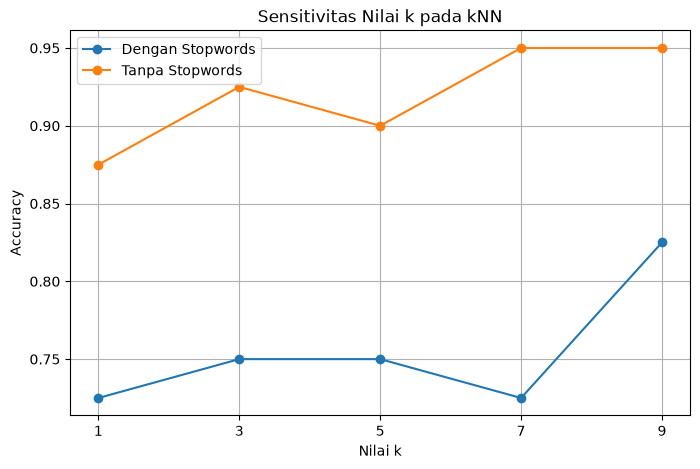

In [37]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    K_VALUES,
    df_knn_with_sw["Accuracy"],
    marker="o",
    label="Dengan Stopwords"
)

plt.plot(
    K_VALUES,
    df_knn_without_sw["Accuracy"],
    marker="o",
    label="Tanpa Stopwords"
)

plt.xlabel(
    "Nilai k"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Sensitivitas Nilai k pada kNN"
)

plt.xticks(
    K_VALUES
)

plt.legend()

plt.grid(
    True
)

plt.show()

In [35]:
print(
    classification_report(
        y_test_nb,
        y_pred,
        target_names=[
            "finance",
            "sport"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     finance       0.83      0.95      0.88        20
       sport       0.94      0.80      0.86        20

    accuracy                           0.88        40
   macro avg       0.88      0.88      0.87        40
weighted avg       0.88      0.88      0.87        40



## 30. Nilai k untuk Evaluasi kNN

Nilai k dengan Accuracy tertinggi pada masing-masing skenario
digunakan untuk menampilkan confusion matrix kNN.

In [38]:
best_k_with_sw_value = int(
    K_VALUES[
        df_knn_with_sw["Accuracy"]
        .values.argmax()
    ]
)

best_k_without_sw_value = int(
    K_VALUES[
        df_knn_without_sw["Accuracy"]
        .values.argmax()
    ]
)

print(
    "Nilai k berdasarkan Accuracy Skenario 1:",
    best_k_with_sw_value
)

print(
    "Nilai k berdasarkan Accuracy Skenario 2:",
    best_k_without_sw_value
)

Nilai k berdasarkan Accuracy Skenario 1: 9
Nilai k berdasarkan Accuracy Skenario 2: 7


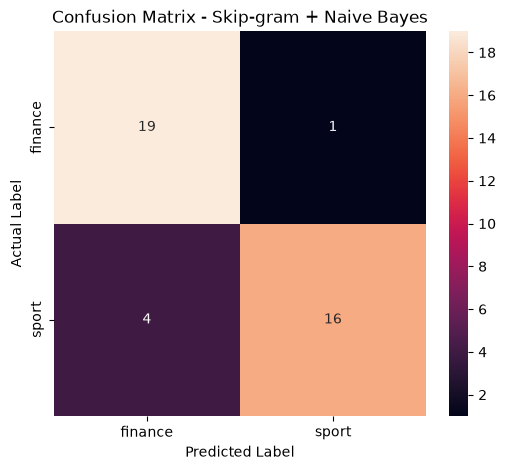

In [37]:
plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "finance",
        "sport"
    ],
    yticklabels=[
        "finance",
        "sport"
    ]
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.title(
    "Confusion Matrix - Skip-gram + Naive Bayes"
)

plt.show()

# 31. Perbandingan Hasil Eksperimen

Hasil klasifikasi dibandingkan berdasarkan:

- Accuracy
- Precision
- Recall
- F1-Score

Perbandingan meliputi:

1. Naive Bayes dengan Stopwords
2. kNN dengan Stopwords
3. Naive Bayes tanpa Stopwords
4. kNN tanpa Stopwords

In [39]:
best_knn_row_with_sw = (
    df_knn_with_sw
    .sort_values(
        "Accuracy",
        ascending=False
    )
    .iloc[0]
)

best_knn_row_without_sw = (
    df_knn_without_sw
    .sort_values(
        "Accuracy",
        ascending=False
    )
    .iloc[0]
)


comparison_results = [

    result_nb_with_sw,

    {
        "Model": best_knn_row_with_sw["Model"],
        "Accuracy": best_knn_row_with_sw["Accuracy"],
        "Precision": best_knn_row_with_sw["Precision"],
        "Recall": best_knn_row_with_sw["Recall"],
        "F1": best_knn_row_with_sw["F1"]
    },

    result_nb_without_sw,

    {
        "Model": best_knn_row_without_sw["Model"],
        "Accuracy": best_knn_row_without_sw["Accuracy"],
        "Precision": best_knn_row_without_sw["Precision"],
        "Recall": best_knn_row_without_sw["Recall"],
        "F1": best_knn_row_without_sw["F1"]
    }
]


df_comparison = pd.DataFrame(
    comparison_results
)

display(
    df_comparison
)

,Model,Accuracy,Precision,Recall,F1
0,NB - Dengan Stopwords,0.800,0.803030,0.800,0.799499
1,kNN k=9 - Dengan Stopwords,0.825,0.832481,0.825,0.824010
2,NB - Tanpa Stopwords,0.875,0.900000,0.875,0.873016
3,kNN k=9 - Tanpa Stopwords,0.950,0.954545,0.950,0.949875


# 32. Confusion Matrix

Confusion matrix digunakan untuk melihat jumlah prediksi benar dan
salah pada masing-masing kelas.

Kelas yang digunakan:

- Finance
- Sport

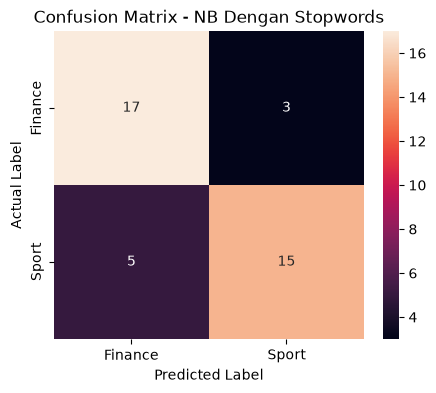

In [40]:
cm_nb_with_sw = confusion_matrix(
    y_test,
    y_pred_nb_with_sw,
    labels=[0, 1]
)

plt.figure(
    figsize=(5, 4)
)

sns.heatmap(
    cm_nb_with_sw,
    annot=True,
    fmt="d",
    xticklabels=[
        "Finance",
        "Sport"
    ],
    yticklabels=[
        "Finance",
        "Sport"
    ]
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.title(
    "Confusion Matrix - NB Dengan Stopwords"
)

plt.show()

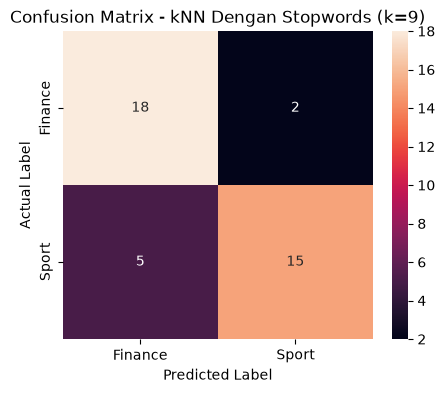

In [41]:
#Confusion matrix kNN dengan stopwords.
y_pred_best_knn_with_sw = (
    knn_predictions_with_sw[
        best_k_with_sw_value
    ]
)

cm_knn_with_sw = confusion_matrix(
    y_test,
    y_pred_best_knn_with_sw,
    labels=[0, 1]
)

plt.figure(
    figsize=(5, 4)
)

sns.heatmap(
    cm_knn_with_sw,
    annot=True,
    fmt="d",
    xticklabels=[
        "Finance",
        "Sport"
    ],
    yticklabels=[
        "Finance",
        "Sport"
    ]
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.title(
    f"Confusion Matrix - kNN Dengan Stopwords (k={best_k_with_sw_value})"
)

plt.show()

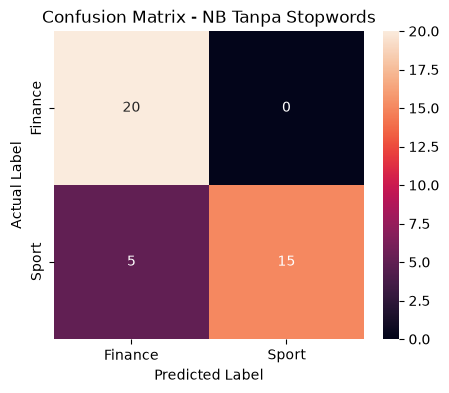

In [42]:
#Confusion matrix NB tanpa stopwords.
cm_nb_without_sw = confusion_matrix(
    y_test,
    y_pred_nb_without_sw,
    labels=[0, 1]
)

plt.figure(
    figsize=(5, 4)
)

sns.heatmap(
    cm_nb_without_sw,
    annot=True,
    fmt="d",
    xticklabels=[
        "Finance",
        "Sport"
    ],
    yticklabels=[
        "Finance",
        "Sport"
    ]
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.title(
    "Confusion Matrix - NB Tanpa Stopwords"
)

plt.show()

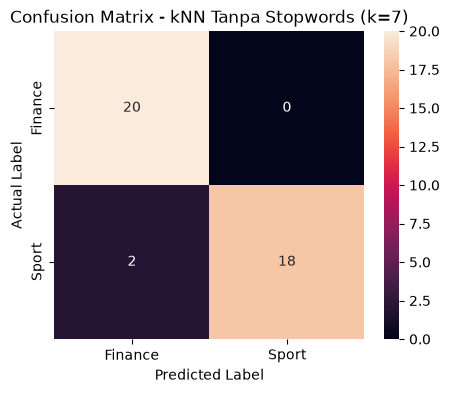

In [43]:
#Confusion matrix kNN tanpa stopwords.
y_pred_best_knn_without_sw = (
    knn_predictions_without_sw[
        best_k_without_sw_value
    ]
)

cm_knn_without_sw = confusion_matrix(
    y_test,
    y_pred_best_knn_without_sw,
    labels=[0, 1]
)

plt.figure(
    figsize=(5, 4)
)

sns.heatmap(
    cm_knn_without_sw,
    annot=True,
    fmt="d",
    xticklabels=[
        "Finance",
        "Sport"
    ],
    yticklabels=[
        "Finance",
        "Sport"
    ]
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.title(
    f"Confusion Matrix - kNN Tanpa Stopwords (k={best_k_without_sw_value})"
)

plt.show()

In [ ]:
# 33. Classification Report

Classification Report digunakan untuk melihat Precision, Recall,
F1-Score, dan jumlah data pada masing-masing kelas.

In [44]:
print(
    "=== NAIVE BAYES DENGAN STOPWORDS ==="
)

print(
    classification_report(
        y_test,
        y_pred_nb_with_sw,
        target_names=[
            "Finance",
            "Sport"
        ],
        zero_division=0
    )
)


print(
    "\n=== NAIVE BAYES TANPA STOPWORDS ==="
)

print(
    classification_report(
        y_test,
        y_pred_nb_without_sw,
        target_names=[
            "Finance",
            "Sport"
        ],
        zero_division=0
    )
)


print(
    "\n=== kNN DENGAN STOPWORDS ==="
)

print(
    classification_report(
        y_test,
        y_pred_best_knn_with_sw,
        target_names=[
            "Finance",
            "Sport"
        ],
        zero_division=0
    )
)


print(
    "\n=== kNN TANPA STOPWORDS ==="
)

print(
    classification_report(
        y_test,
        y_pred_best_knn_without_sw,
        target_names=[
            "Finance",
            "Sport"
        ],
        zero_division=0
    )
)

=== NAIVE BAYES DENGAN STOPWORDS ===
              precision    recall  f1-score   support

     Finance       0.77      0.85      0.81        20
       Sport       0.83      0.75      0.79        20

    accuracy                           0.80        40
   macro avg       0.80      0.80      0.80        40
weighted avg       0.80      0.80      0.80        40


=== NAIVE BAYES TANPA STOPWORDS ===
              precision    recall  f1-score   support

     Finance       0.80      1.00      0.89        20
       Sport       1.00      0.75      0.86        20

    accuracy                           0.88        40
   macro avg       0.90      0.88      0.87        40
weighted avg       0.90      0.88      0.87        40


=== kNN DENGAN STOPWORDS ===
              precision    recall  f1-score   support

     Finance       0.78      0.90      0.84        20
       Sport       0.88      0.75      0.81        20

    accuracy                           0.82        40
   macro avg       0.83 

In [ ]:
## Implementasi Word2Vec Skip-Gram dengan Gensim

Pada bagian ini dilakukan implementasi Word2Vec menggunakan algoritma Skip-Gram dengan library Gensim sebagai metode embedding tambahan.

Model Word2Vec dilatih menggunakan data training pada masing-masing skenario preprocessing. Setiap berita kemudian direpresentasikan menjadi satu vektor dokumen menggunakan metode Mean Pooling.

Vektor dokumen hasil Word2Vec selanjutnya digunakan sebagai fitur untuk klasifikasi menggunakan Gaussian Naive Bayes.

Implementasi dilakukan pada dua skenario:
1. Dengan Stopwords
2. Tanpa Stopwords

Metode Co-occurrence Matrix + SVD yang telah dilakukan sebelumnya tetap dipertahankan sebagai metode pembanding.

## Visualisasi Ruang Vektor Dokumen dengan PCA

PCA (Principal Component Analysis) digunakan untuk mereduksi vektor dokumen
berdimensi 12 menjadi dua dimensi, yaitu PC1 dan PC2.

Visualisasi dilakukan pada dua skenario preprocessing:
1. Dengan Stopwords
2. Tanpa Stopwords

Visualisasi ini digunakan untuk melihat persebaran dokumen Finance dan Sport
dalam ruang vektor hasil word embedding.

In [45]:
def plot_document_pca(X_train, X_test, y_train, y_test, title):
    X_all = np.vstack([X_train, X_test])
    y_all = np.concatenate([np.array(y_train), np.array(y_test)])

    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))

    for label, name in [(0, "Finance"), (1, "Sport")]:
        mask = y_all == label

        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            label=name,
            alpha=0.7
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

## PCA Skenario Dengan Stopwords

Visualisasi berikut menunjukkan persebaran dokumen Finance dan Sport
berdasarkan vektor dokumen pada skenario dengan stopwords.

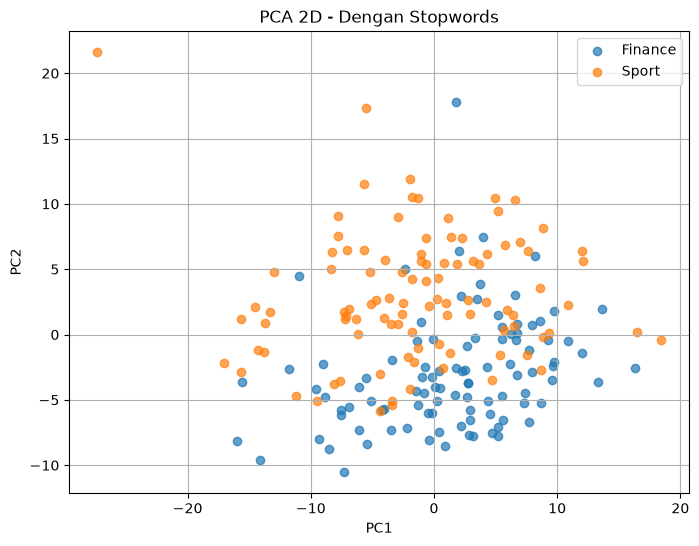

In [46]:
plot_document_pca(
    X_train_with_sw,
    X_test_with_sw,
    y_train,
    y_test,
    "PCA 2D - Dengan Stopwords"
)

## PCA Skenario Tanpa Stopwords

Visualisasi berikut menunjukkan persebaran dokumen Finance dan Sport
berdasarkan vektor dokumen pada skenario tanpa stopwords.

In [ ]:
plot_document_pca(
    X_train_without_sw,
    X_test_without_sw,
    y_train,
    y_test,
    "PCA 2D - Tanpa Stopwords"
)

# Penyimpanan Hasil Eksperimen

Hasil eksperimen disimpan dalam beberapa file Excel untuk memudahkan
analisis dan dokumentasi hasil penelitian.

File yang disimpan meliputi:
- Statistik corpus.
- Perbandingan performa model.
- Sensitivitas nilai k pada kNN.
- Embedding data training dan testing pada kedua skenario preprocessing.

In [ ]:
df_corpus_stats.to_excel(
    "statistik_corpus_tugas4.xlsx",
    index=False
)

df_comparison.to_excel(
    "perbandingan_model_tugas4.xlsx",
    index=False
)

df_sensitivity_k.to_excel(
    "sensitivitas_k_knn_tugas4.xlsx",
    index=False
)

train_embedding_with_sw = pd.DataFrame(
    X_train_with_sw,
    columns=[f"Dim_{i}" for i in range(1, EMBEDDING_DIM + 1)]
)

train_embedding_with_sw["label"] = np.array(y_train)

test_embedding_with_sw = pd.DataFrame(
    X_test_with_sw,
    columns=[f"Dim_{i}" for i in range(1, EMBEDDING_DIM + 1)]
)

test_embedding_with_sw["label"] = np.array(y_test)

train_embedding_without_sw = pd.DataFrame(
    X_train_without_sw,
    columns=[f"Dim_{i}" for i in range(1, EMBEDDING_DIM + 1)]
)

train_embedding_without_sw["label"] = np.array(y_train)

test_embedding_without_sw = pd.DataFrame(
    X_test_without_sw,
    columns=[f"Dim_{i}" for i in range(1, EMBEDDING_DIM + 1)]
)

test_embedding_without_sw["label"] = np.array(y_test)

train_embedding_with_sw.to_excel(
    "embedding_training_dengan_stopwords.xlsx",
    index=False
)

test_embedding_with_sw.to_excel(
    "embedding_testing_dengan_stopwords.xlsx",
    index=False
)

train_embedding_without_sw.to_excel(
    "embedding_training_tanpa_stopwords.xlsx",
    index=False
)

test_embedding_without_sw.to_excel(
    "embedding_testing_tanpa_stopwords.xlsx",
    index=False
)

print("Semua hasil berhasil disimpan.")

# Kesimpulan

Pada tugas ini dilakukan klasifikasi teks berita menggunakan representasi
word embedding berbasis Co-occurrence Matrix dan Singular Value
Decomposition (SVD).

Eksperimen dilakukan menggunakan dua skenario preprocessing, yaitu
dengan stopwords dan tanpa stopwords.

Tahapan pengolahan data meliputi preprocessing teks, tokenisasi,
pembentukan vocabulary, pembuatan Co-occurrence Matrix dengan sliding
window, reduksi dimensi menggunakan SVD, pembentukan word embedding,
serta mean pooling untuk memperoleh representasi vektor dokumen.

Klasifikasi dilakukan menggunakan Gaussian Naive Bayes dan
k-Nearest Neighbors (kNN).

Pada kNN digunakan beberapa nilai k, yaitu 1, 3, 5, 7, dan 9.
Performa model dievaluasi menggunakan Accuracy, Precision, Recall,
dan F1-Score. Evaluasi juga dilengkapi dengan Classification Report
dan Confusion Matrix.

Hasil dari kedua skenario preprocessing dibandingkan untuk mengetahui
pengaruh penggunaan stopwords terhadap hasil klasifikasi.

Selain itu, PCA digunakan untuk memvisualisasikan persebaran dokumen
Finance dan Sport dalam ruang vektor dua dimensi.